In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import confusion_matrix, mean_absolute_error, mean_squared_error, r2_score


water_pot = pd.read_csv("C:\\Users\\Admin\\Documents\\arc_model_core\\ml_docs\\Datasets\\water-potability.csv")
print(f":> DATASET SHAPE: {water_pot.shape}")

water_pot.head(10)

:> DATASET SHAPE: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


In [16]:
# DISPLAY DATASET INFORMATION (DATA TYPES, NON-NULL COUNTS, MEMORY USAGE)
water_pot.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [17]:
# DISPLAY SUMMARY STATISTICS OF THE DATASET
water_pot.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [40]:
# CHECK FOR MISSING VALUES IN EACH COLUMN
print("=>> MISSING VALUES PER COLUMN (BEFORE IMPUTATION) >>")
display(water_pot.isnull().sum())

=>> MISSING VALUES PER COLUMN (BEFORE IMPUTATION) >>


ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [19]:
# IMPUTE NUMERICAL COLUMNS WITH MEAN VALUES
water_pot['ph'] = water_pot['ph'].fillna(water_pot['ph'].mean())
water_pot["Sulfate"] = water_pot["Sulfate"].fillna(water_pot["Sulfate"].mean())
water_pot["Trihalomethanes"] = water_pot["Trihalomethanes"].fillna(water_pot["Trihalomethanes"].mean())

# VERIFY THAT ALL MISSING VALUES HAVE BEEN HANDLED
print("=>> MISSING VALUES PER COLUMN (AFTER IMPUTATION) >>")
display(water_pot.isnull().sum())

=>> MISSING VALUES PER COLUMN (AFTER IMPUTATION) >>


ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

=>> VISUALIZING DISTRIBUTION OF NUMERICAL FEATURES >>

===============> DISTRIBUTION OF 'PH' <===============


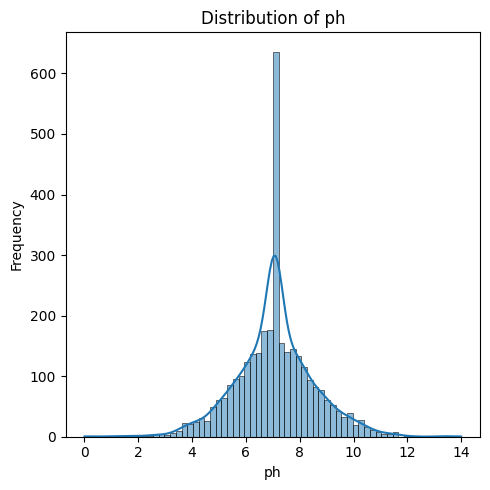


===============> DISTRIBUTION OF 'HARDNESS' <===============


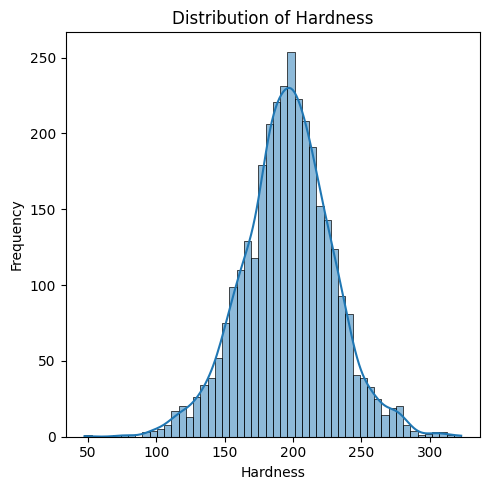


===============> DISTRIBUTION OF 'SOLIDS' <===============


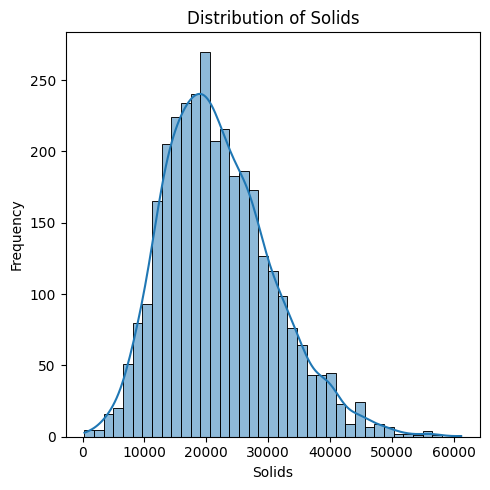


===============> DISTRIBUTION OF 'CHLORAMINES' <===============


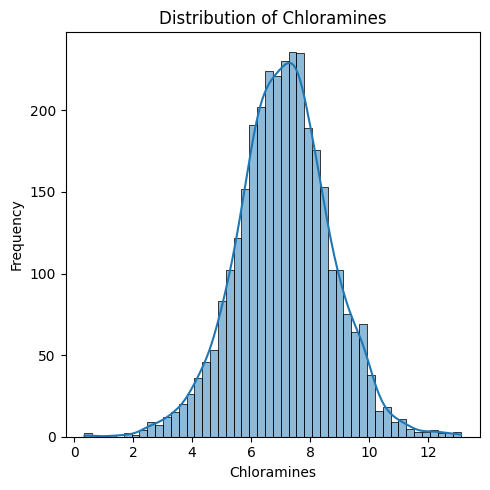


===============> DISTRIBUTION OF 'SULFATE' <===============


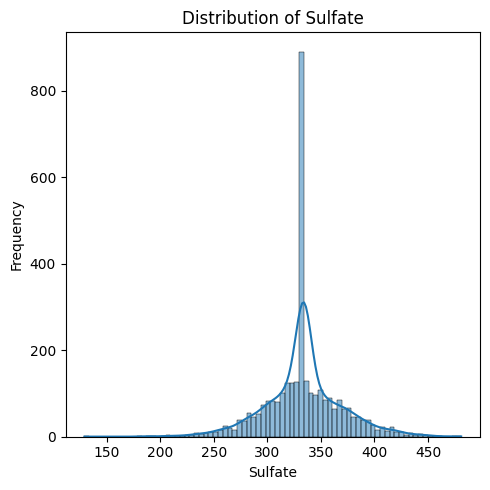


===============> DISTRIBUTION OF 'CONDUCTIVITY' <===============


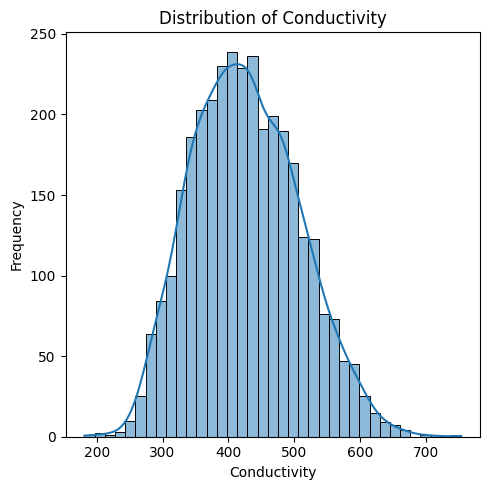


===============> DISTRIBUTION OF 'ORGANIC_CARBON' <===============


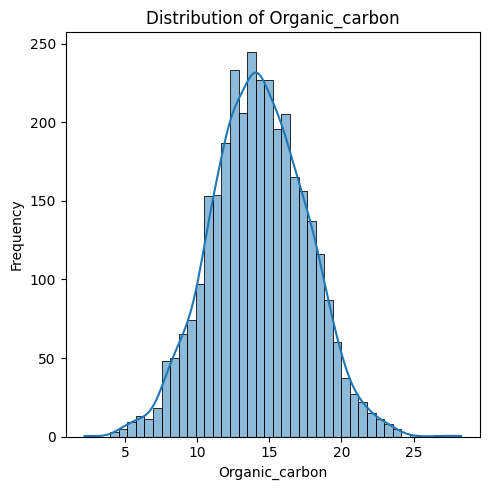


===============> DISTRIBUTION OF 'TRIHALOMETHANES' <===============


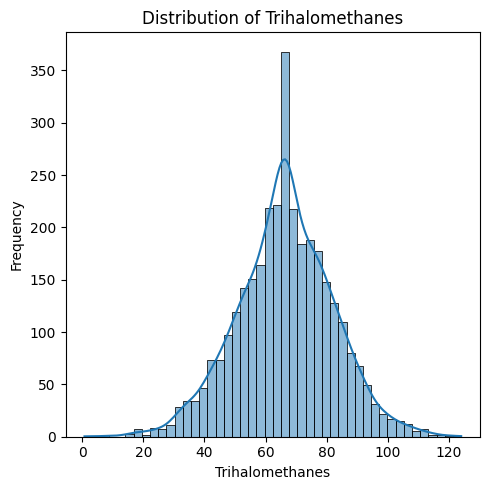


===============> DISTRIBUTION OF 'TURBIDITY' <===============


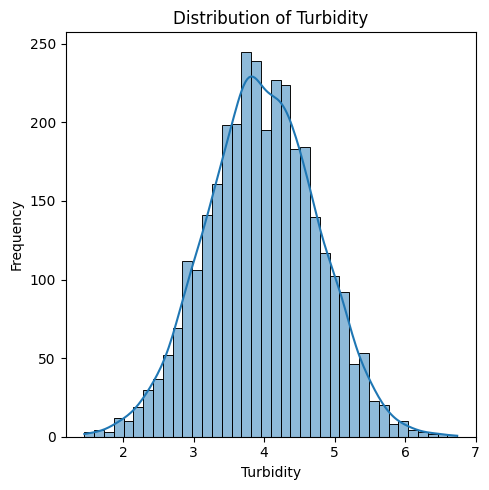

In [20]:
# DEFINE NUMERICAL FEATURES FOR VISUALIZATION
numerical_features = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity",
]


# VISUALIZE DISTRIBUTION OF EACH NUMERICAL FEATURE
print("=>> VISUALIZING DISTRIBUTION OF NUMERICAL FEATURES >>")
for feature in numerical_features:
    plt.figure(figsize=(5,5))
    sns.histplot(water_pot[feature], kde=True)

    print(f"\n===============> DISTRIBUTION OF '{feature.upper()}' <===============")
    plt.title(f"Distribution of {feature}")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [21]:
# SEPARATE FEATURES (X) AND TARGET VARIABLE (y)
X, y = water_pot.drop(columns=["Potability"], axis=0), water_pot["Potability"]

# SPLIT THE DATA INTO TRAINING AND TESTING SETS (75% TRAIN, 25% TEST)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [22]:
# DISPLAY THE SHAPES OF SPLIT DATASETS
print(f":> TRAINING FEATURES SHAPE (X_train): {X_train.shape}")
print(f":> TESTING FEATURES SHAPE (X_test): {X_test.shape}")
print(f":> TRAINING TARGET SHAPE (y_train): {y_train.shape}")
print(f":> TESTING TARGET SHAPE (y_test): {y_test.shape}")

:> TRAINING FEATURES SHAPE (X_train): (2457, 9)
:> TESTING FEATURES SHAPE (X_test): (819, 9)
:> TRAINING TARGET SHAPE (y_train): (2457,)
:> TESTING TARGET SHAPE (y_test): (819,)


In [37]:
# INITIALIZE LOGISTIC REGRESSION MODEL
logistic = LogisticRegression(max_iter=1000)


# TRAIN THE MODEL ON TRAINING DATA
logistic.fit(X_train, y_train)
print("=> MODEL TRAINING COMPLETED SUCCESSFULLY")

=> MODEL TRAINING COMPLETED SUCCESSFULLY


In [24]:
# MAKE PREDICTIONS ON THE TEST SET
y_predicted = logistic.predict(X_test)


# CALCULATE AND DISPLAY MODEL ACCURACY
accuracy = logistic.score(X_test, y_test) * 100
print(f":> MODEL ACCURACY: {accuracy:.2f}%")

:> MODEL ACCURACY: 62.27%


In [35]:
# GENERATE CONFUSION MATRIX
confusion_mat = confusion_matrix(y_test, y_predicted)
print("=>> CONFUSION MATRIX >>")
print(confusion_mat)

=>> CONFUSION MATRIX >>
[[510   0]
 [309   0]]


In [26]:
# EXTRACT AND DISPLAY CONFUSION MATRIX COMPONENTS
tn, fp, fn, tp = confusion_mat.ravel()

print(f"=>> CONFUSION MATRIX BREAKDOWN >>")
print("=" * 50)
print(f":> TRUE NEGATIVE (Correctly predicted Non-Potable): {tn}")
print(f":> FALSE POSITIVE (Incorrectly predicted Potable): {fp}")
print(f":> FALSE NEGATIVE (Incorrectly predicted Non-Potable): {fn}")
print(f":> TRUE POSITIVE (Correctly predicted Potable): {tp}")
print("=" * 50)

=>> CONFUSION MATRIX BREAKDOWN >>
:> TRUE NEGATIVE (Correctly predicted Non-Potable): 510
:> FALSE POSITIVE (Incorrectly predicted Potable): 0
:> FALSE NEGATIVE (Incorrectly predicted Non-Potable): 309
:> TRUE POSITIVE (Correctly predicted Potable): 0


In [34]:
# CALCULATE ADDITIONAL METRICS
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = (2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0)


print("=>> ADDITIONAL CLASSIFICATION METRICS >>")
print("=" * 50)
print(f":> PRECISION: {precision:.4f}")
print(f":> RECALL: {recall:.4f}")
print(f":> F1-SCORE: {f1_score:.4f}")
print("=" * 50)

=>> ADDITIONAL CLASSIFICATION METRICS >>
:> PRECISION: 0.0000
:> RECALL: 0.0000
:> F1-SCORE: 0.0000


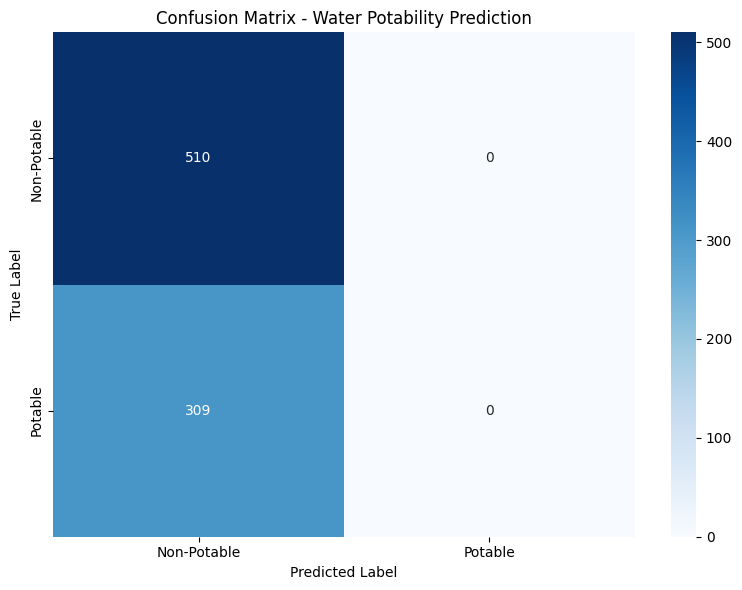

In [33]:
# VISUALIZE CONFUSION MATRIX USING HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(
    confusion_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Potable", "Potable"],
    yticklabels=["Non-Potable", "Potable"])

plt.title("Confusion Matrix - Water Potability Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [32]:
# OPTIONAL: PERFORM CROSS-VALIDATION
cv_predictions = cross_val_predict(logistic, X, y, cv=5)
cv_accuracy = (cv_predictions == y).mean() * 100

print("=>> PERFORMING CROSS-VALIDATION >>")
print(f"\n:> CROSS-VALIDATION ACCURACY (5-Fold): {cv_accuracy:.2f}%")

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

=>> PERFORMING CROSS-VALIDATION >>

:> CROSS-VALIDATION ACCURACY (5-Fold): 60.99%


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
# DISPLAY CLASS DISTRIBUTION
print("=>> TARGET CLASS DISTRIBUTION >>")
print("=" * 50)
print(f":> NON-POTABLE (0): {y.value_counts()[0]} SAMPLES ({y.value_counts(normalize=True)[0] * 100:.1f}%)")
print(f":> POTABLE (1): {y.value_counts()[1]} SAMPLES ({y.value_counts(normalize=True)[0] * 100:.1f}%)")
print("=" * 50)

=>> TARGET CLASS DISTRIBUTION >>
:> NON-POTABLE (0): 1998 SAMPLES (61.0%)
:> POTABLE (1): 1278 SAMPLES (61.0%)
